# Supervised Learning Case Study: Bank Marketing Campaign Response

## Problem Statement
Predict whether a customer will subscribe to a term deposit after a marketing call, to help the bank target future campaigns more efficiently.

## Dataset
**Bank Marketing** dataset -- ~45,000 records with demographic fields (age, job, marital, education), campaign fields (contact, month, duration, campaign, pdays, previous, poutcome), and the binary `Target` outcome.

## Approach
Extensive EDA across numeric and categorical features (boxplots, count plots split by target, correlation heatmap), one-hot encoding of categoricals, Min-Max scaling, then three models compared: Logistic Regression, KNN, and Random Forest.

## Conclusion
All three models are evaluated via confusion matrix, accuracy, precision, recall, and F1-score, with Random Forest's feature importances surfaced to show which campaign/demographic factors matter most.


In [164]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

pandas reads the data as dataframe. The processing of data is done as a dataframe for conveniance in handling.
numpy package is used to perform mathematical computation if any seaboen or matplotlib is used for visualization scipy package is used for statistical 

numpy used for working with arrays. It also has functions for working in domain of linear algebra, fourier transform, and matrices.

Creating various types of plots: Line plots, scatter plots, bar plots, histograms, pie charts, and many more.
Customizing plots: Adding titles, labels, legends, gridlines, annotations, and changing colors, markers, and line styles.
Multiple plots in one figure: Creating subplots to display multiple plots together.
Saving plots: Saving plots to different file formats like PNG, JPEG, PDF, etc.

used for data visualization and creating statistical graphics. It's built on top of the Matplotlib library and integrates with Pandas data structures. 

In [8]:
data=pd.read_csv('bank-full.csv')

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  Target     45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [10]:
data.shape

(45211, 17)

In [19]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


Checking the descriptive statistics of data. The 

In [14]:
data.isnull().values.any()

False

In [43]:
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [44]:
data_num=data.describe().columns
print(data_num)

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')


In [16]:
print("Categorical")
data_cat=data.describe(include=[object]).columns
print(data_cat)

Categorical
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'Target'],
      dtype='object')


displays the categorical column names

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'balance'}>,
        <Axes: title={'center': 'day'}>],
       [<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>,
        <Axes: title={'center': 'pdays'}>],
       [<Axes: title={'center': 'previous'}>, <Axes: >, <Axes: >]],
      dtype=object)

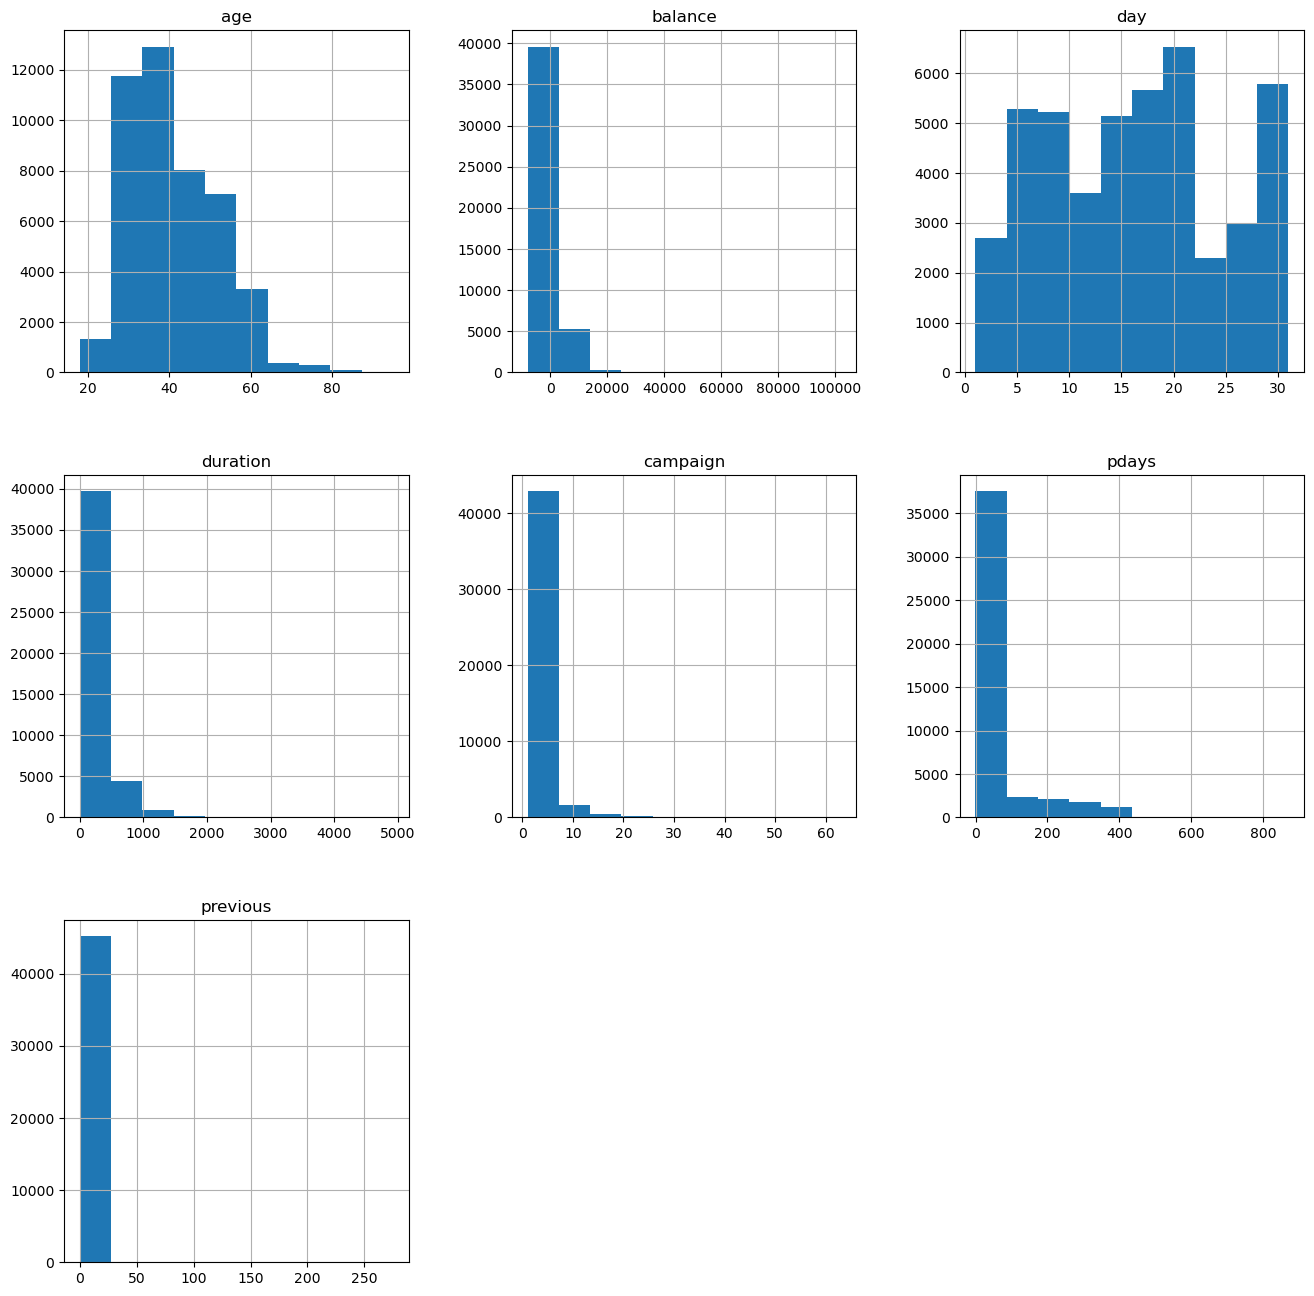

In [45]:
#visualizing numeric attributes
data.hist(column=data_num,figsize=(16,16))

Histogram of all numeric columns of data visualization
Majotity of the customers in the data are belonging to age group of 20 -40
Majority customers balance is low.
Average campaign is 1-8

<Axes: xlabel='Target', ylabel='age'>

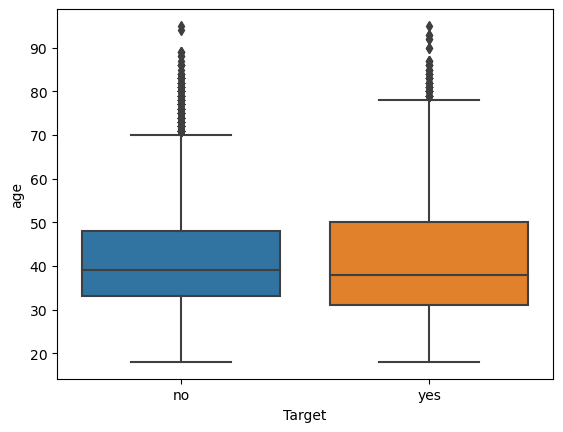

In [20]:
sns.boxplot(data=data,x='Target',y='age')

The median age for both the groups (subscribed and not subscribed) is around 37 - 40. 
There is an overlapping for agesfor both groups of target which indicates that age is not a goodindicator to predict which  customer will  subscribe or not subscribe

In [28]:
#target and campaign
#target and duration
#target and pdays

<Axes: xlabel='Target', ylabel='campaign'>

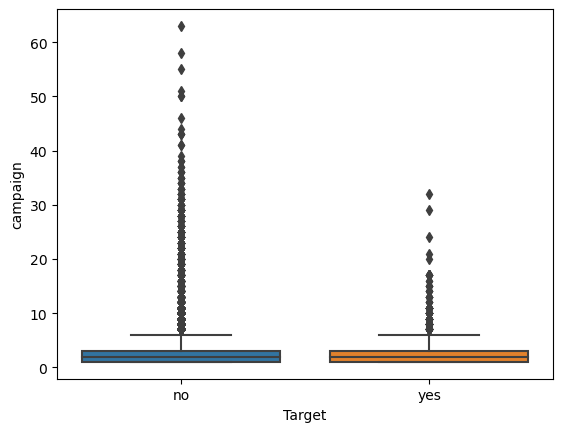

In [30]:
sns.boxplot(data=data,x='Target', y='campaign')

<Axes: xlabel='Target', ylabel='duration'>

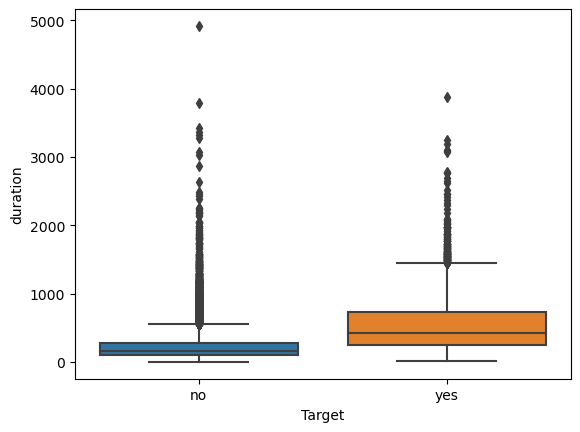

In [29]:
sns.boxplot(data=data,x='Target', y='duration')

From the plot it is clear that duration can be useful for predicting the target variable

<Axes: xlabel='Target', ylabel='pdays'>

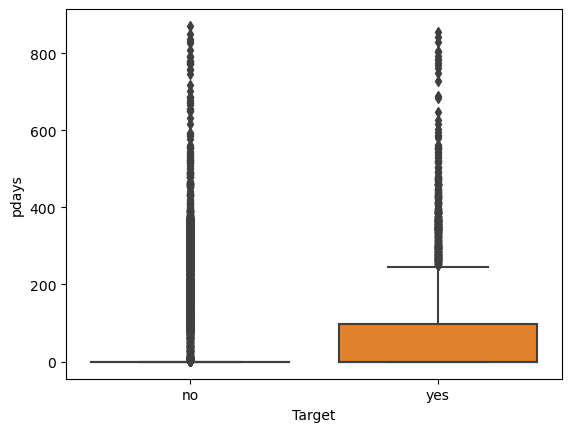

In [31]:
sns.boxplot(data=data,x='Target', y='pdays')

From the plot above its inferred more frequent contact to customers, more the subscription to term deposit

In [34]:
data['pdays'].value_counts()

-1      36954
 182      167
 92       147
 91       126
 183      126
        ...  
 449        1
 452        1
 648        1
 595        1
 530        1
Name: pdays, Length: 559, dtype: int64

<Axes: xlabel='Target', ylabel='previous'>

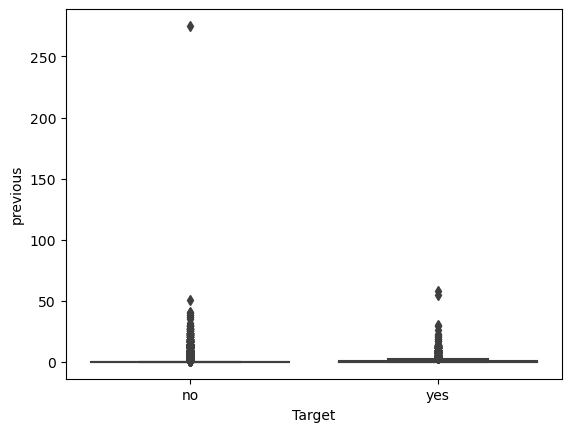

In [36]:
sns.boxplot(data=data,x='Target', y='previous')

In [38]:
data['previous'].value_counts()

0      36954
1       2772
2       2106
3       1142
4        714
5        459
6        277
7        205
8        129
9         92
10        67
11        65
12        44
13        38
15        20
14        19
17        15
16        13
19        11
20         8
23         8
18         6
22         6
24         5
27         5
21         4
29         4
25         4
30         3
38         2
37         2
26         2
28         2
51         1
275        1
58         1
32         1
40         1
55         1
35         1
41         1
Name: previous, dtype: int64

<Axes: xlabel='Target', ylabel='day'>

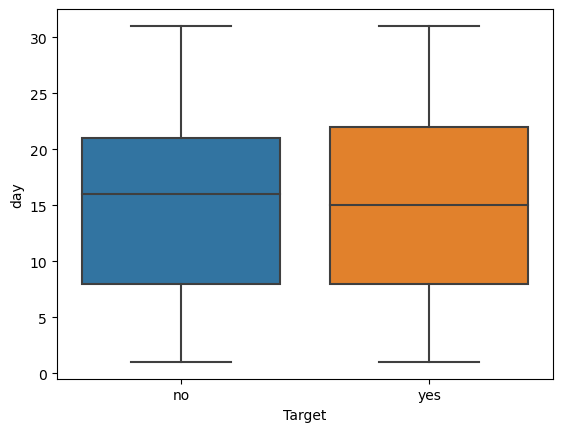

In [39]:
sns.boxplot(data=data,x='Target', y='day')

C:\Users\moham\AppData\Local\Temp\ipykernel_24960\2128826405.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation=data.corr()


<Axes: >

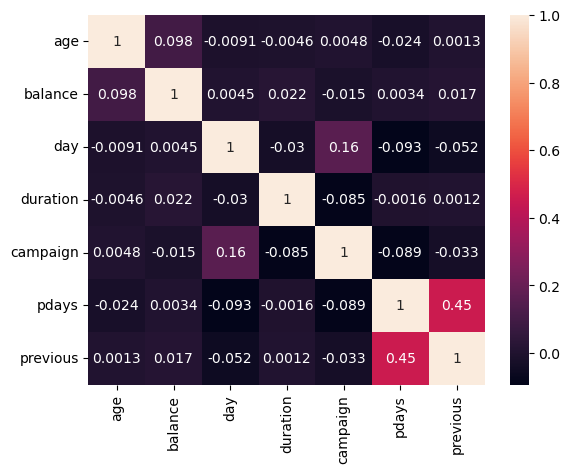

In [42]:
correlation=data.corr(numeric_only=True)  # numeric_only=True: skip non-numeric columns (fixed for pandas 2.x+)
sns.heatmap(correlation,annot=True)

slight correlation between previous and pdays observed

In [49]:
#num_data=data[['age','balance', 'day', 'duration', 'campaign', 'pdays', 'previous']]
#correlation=num_data.corr()

[Text(0, 0, 'management'),
 Text(1, 0, 'technician'),
 Text(2, 0, 'entrepreneur'),
 Text(3, 0, 'blue-collar'),
 Text(4, 0, 'unknown'),
 Text(5, 0, 'retired'),
 Text(6, 0, 'admin.'),
 Text(7, 0, 'services'),
 Text(8, 0, 'self-employed'),
 Text(9, 0, 'unemployed'),
 Text(10, 0, 'housemaid'),
 Text(11, 0, 'student')]

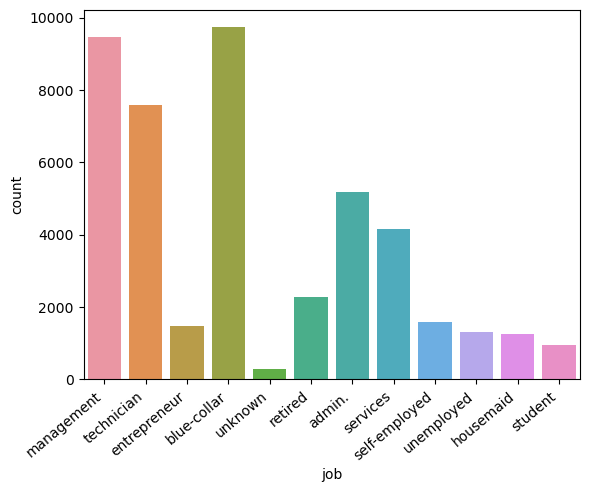

In [54]:
#visualizing categorical variables
ax=sns.countplot(x='job',data=data)
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha="right")

Most of the customers have job "management", "Blue-collar"

[Text(0, 0, 'management'),
 Text(1, 0, 'technician'),
 Text(2, 0, 'entrepreneur'),
 Text(3, 0, 'blue-collar'),
 Text(4, 0, 'unknown'),
 Text(5, 0, 'retired'),
 Text(6, 0, 'admin.'),
 Text(7, 0, 'services'),
 Text(8, 0, 'self-employed'),
 Text(9, 0, 'unemployed'),
 Text(10, 0, 'housemaid'),
 Text(11, 0, 'student')]

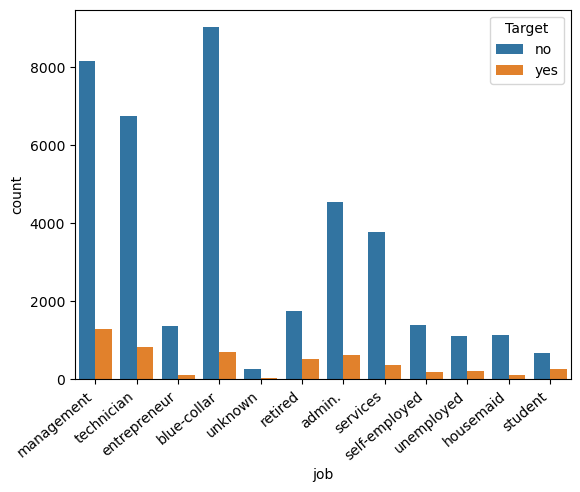

In [58]:
ax=sns.countplot(x='job',data=data,hue='Target')
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha="right")

From the above plot customers from management has the highest rate of subscrinbing the loan

[Text(0, 0, 'married'), Text(1, 0, 'single'), Text(2, 0, 'divorced')]

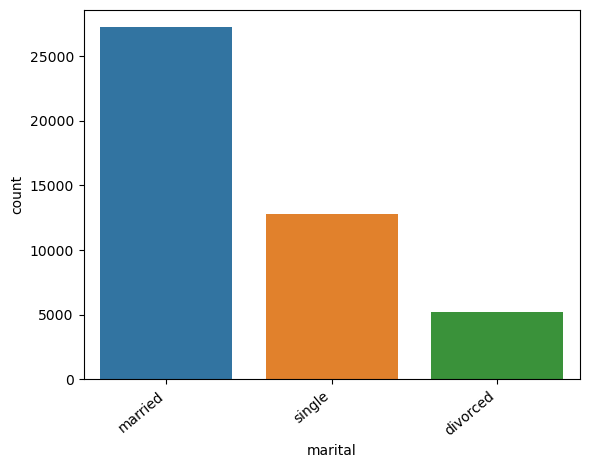

In [59]:
ax=sns.countplot(x='marital',data=data)
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha="right")

[Text(0, 0, 'married'), Text(1, 0, 'single'), Text(2, 0, 'divorced')]

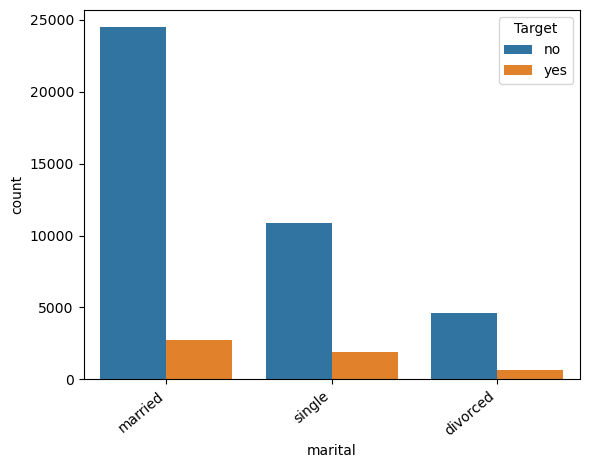

In [60]:
ax=sns.countplot(x='marital',data=data,hue="Target")
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha="right")

[Text(0, 0, 'tertiary'),
 Text(1, 0, 'secondary'),
 Text(2, 0, 'unknown'),
 Text(3, 0, 'primary')]

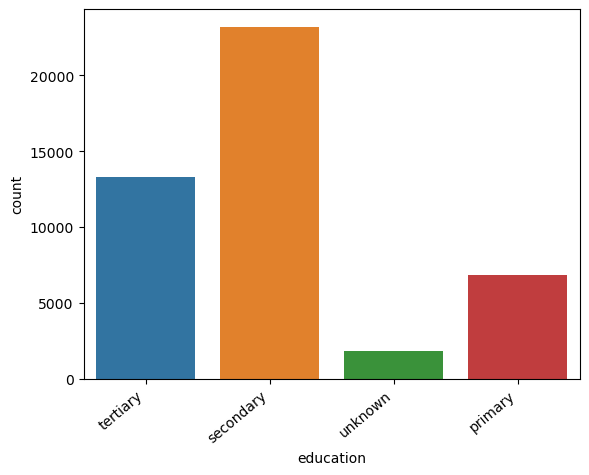

In [61]:
ax=sns.countplot(x='education',data=data)
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha="right")

[Text(0, 0, 'tertiary'),
 Text(1, 0, 'secondary'),
 Text(2, 0, 'unknown'),
 Text(3, 0, 'primary')]

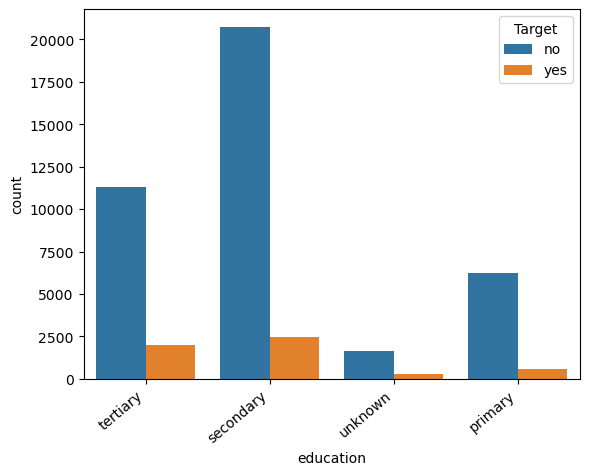

In [62]:
ax=sns.countplot(x='education',data=data,hue="Target")
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha="right")

Customers with secondory education is subscribing more loan

In [63]:
#default
#housing
#Loan
#contact
#month
#poutcome

[Text(0, 0, 'no'), Text(1, 0, 'yes')]

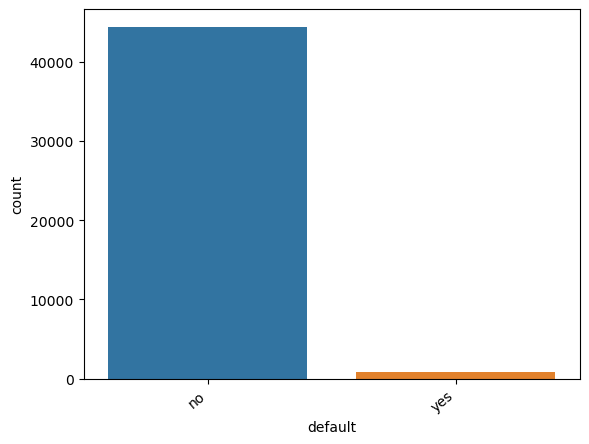

In [64]:
ax=sns.countplot(x='default',data=data)
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha="right")

[Text(0, 0, 'no'), Text(1, 0, 'yes')]

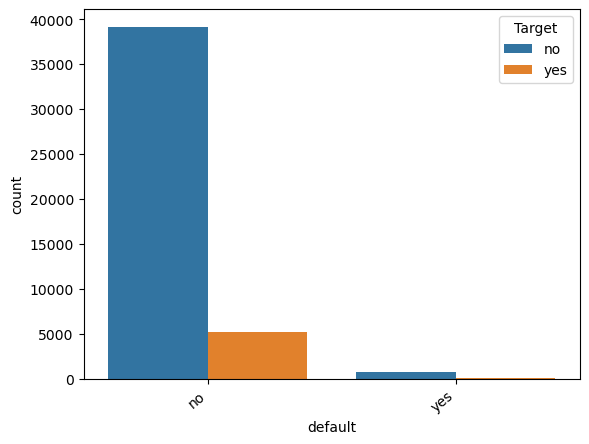

In [65]:
ax=sns.countplot(x='default',data=data,hue="Target")
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha="right")

Mst of the non defaulters are subscribing more

[Text(0, 0, 'yes'), Text(1, 0, 'no')]

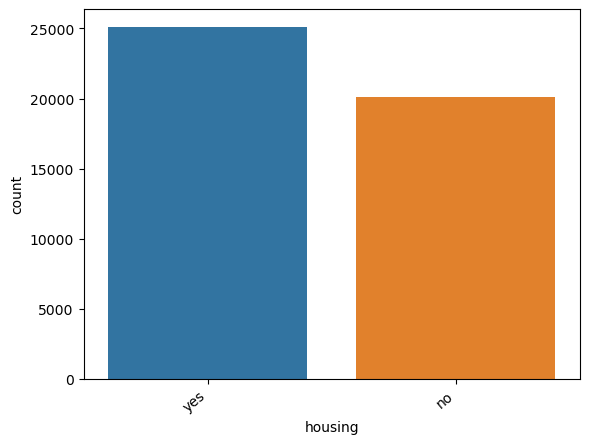

In [66]:
ax=sns.countplot(x='housing',data=data)
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha="right")

[Text(0, 0, 'yes'), Text(1, 0, 'no')]

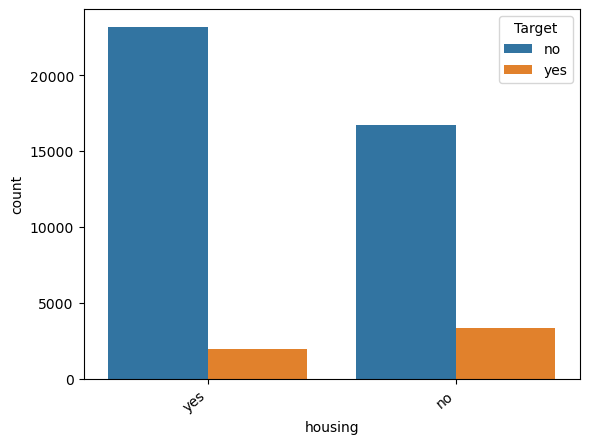

In [67]:
ax=sns.countplot(x='housing',data=data,hue="Target")
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha="right")

Most of the customers without housing loan are subscribing the loan

[Text(0, 0, 'no'), Text(1, 0, 'yes')]

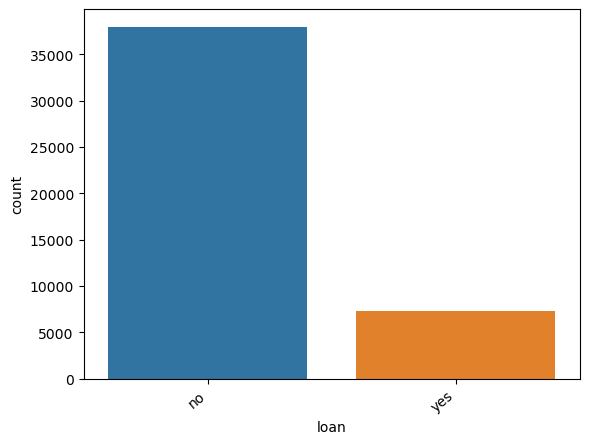

In [69]:
ax=sns.countplot(x='loan',data=data)
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha="right")

[Text(0, 0, 'no'), Text(1, 0, 'yes')]

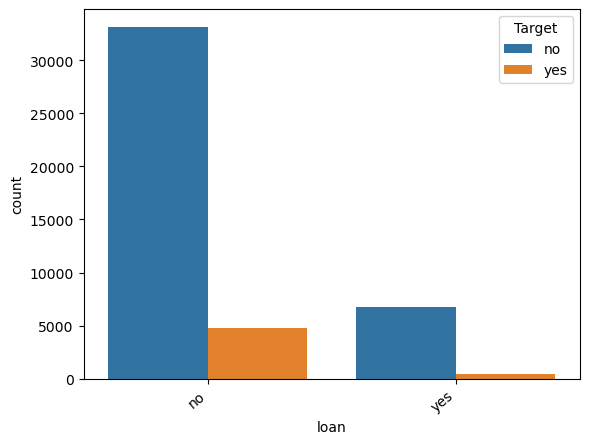

In [70]:
ax=sns.countplot(x='loan',data=data,hue="Target")
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha="right")

Most of the customers donot have personal loan

[Text(0, 0, 'unknown'), Text(1, 0, 'cellular'), Text(2, 0, 'telephone')]

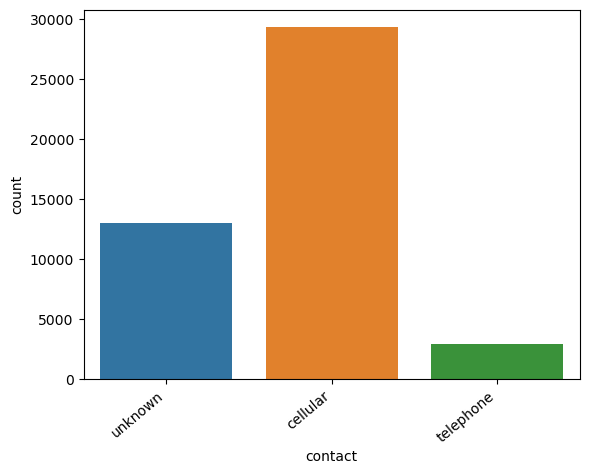

In [71]:
ax=sns.countplot(x='contact',data=data)
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha="right")

[Text(0, 0, 'unknown'), Text(1, 0, 'cellular'), Text(2, 0, 'telephone')]

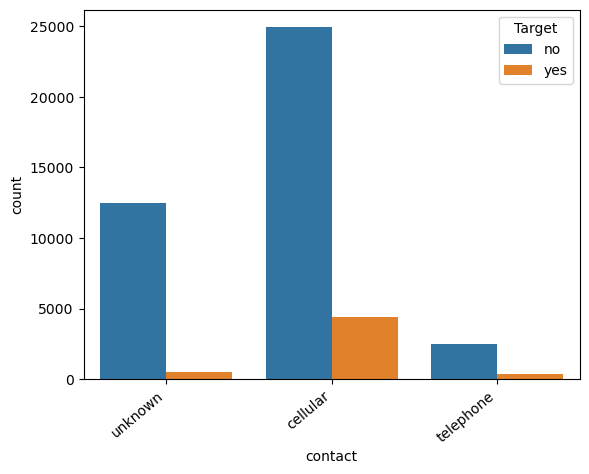

In [72]:
ax=sns.countplot(x='contact',data=data,hue="Target")
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha="right")

Most of the customers contacted through cellular type is subscribing for loan

[Text(0, 0, 'may'),
 Text(1, 0, 'jun'),
 Text(2, 0, 'jul'),
 Text(3, 0, 'aug'),
 Text(4, 0, 'oct'),
 Text(5, 0, 'nov'),
 Text(6, 0, 'dec'),
 Text(7, 0, 'jan'),
 Text(8, 0, 'feb'),
 Text(9, 0, 'mar'),
 Text(10, 0, 'apr'),
 Text(11, 0, 'sep')]

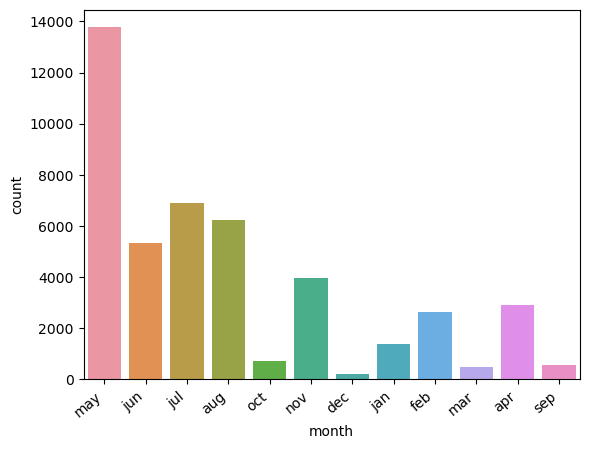

In [73]:
ax=sns.countplot(x='month',data=data)
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha="right")

[Text(0, 0, 'may'),
 Text(1, 0, 'jun'),
 Text(2, 0, 'jul'),
 Text(3, 0, 'aug'),
 Text(4, 0, 'oct'),
 Text(5, 0, 'nov'),
 Text(6, 0, 'dec'),
 Text(7, 0, 'jan'),
 Text(8, 0, 'feb'),
 Text(9, 0, 'mar'),
 Text(10, 0, 'apr'),
 Text(11, 0, 'sep')]

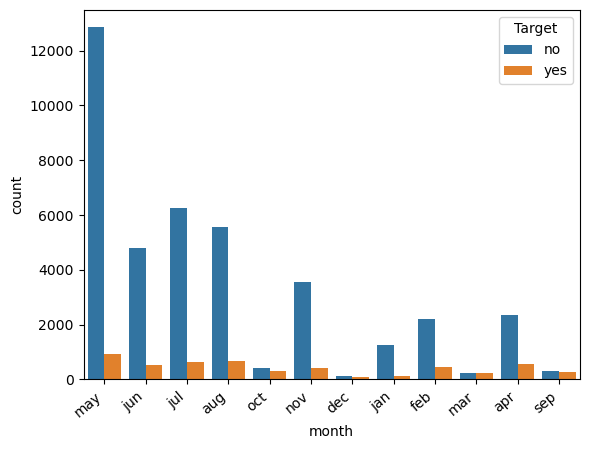

In [76]:
ax=sns.countplot(x='month',data=data,hue="Target")
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha="right")

MOst of the customers  contacted in the month of may is subscribing the loan

[Text(0, 0, 'unknown'),
 Text(1, 0, 'failure'),
 Text(2, 0, 'other'),
 Text(3, 0, 'success')]

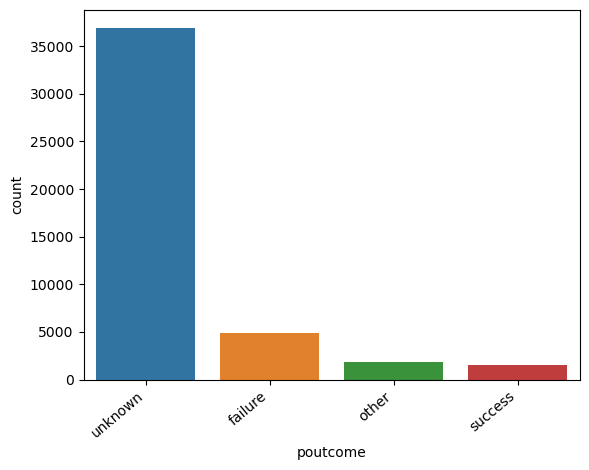

In [77]:
ax=sns.countplot(x='poutcome',data=data)
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha="right")

[Text(0, 0, 'unknown'),
 Text(1, 0, 'failure'),
 Text(2, 0, 'other'),
 Text(3, 0, 'success')]

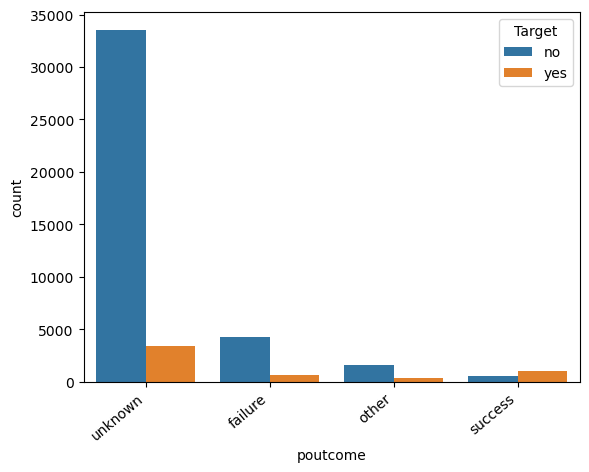

In [78]:
ax=sns.countplot(x='poutcome',data=data,hue="Target")
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha="right")

In [79]:
#Data

In [80]:
data.isnull().values.any()

False

Above results conclude that no NAN present in the dataset

In [81]:
#Checking for categorical data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  Target     45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
#categorical values are identified
#convert catgorical to numeric

In [86]:
#one hot encodining
cols=data.select_dtypes(include=['object']).columns

In [88]:
data=pd.concat([data,pd.get_dummies(data[cols])],axis=1)

In [89]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,...,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown,Target_no,Target_yes
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,1,0,0,0,0,0,0,1,1,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,...,1,0,0,0,0,0,0,1,1,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,1,0,0,0,0,0,0,1,1,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,...,1,0,0,0,0,0,0,1,1,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,...,1,0,0,0,0,0,0,1,1,0


In [91]:
data=data.drop(['job','marital','education','default','housing','loan','contact','month','poutcome','Target','duration'],axis=1)

In [92]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 52 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  45211 non-null  int64
 1   balance              45211 non-null  int64
 2   day                  45211 non-null  int64
 3   campaign             45211 non-null  int64
 4   pdays                45211 non-null  int64
 5   previous             45211 non-null  int64
 6   job_admin.           45211 non-null  uint8
 7   job_blue-collar      45211 non-null  uint8
 8   job_entrepreneur     45211 non-null  uint8
 9   job_housemaid        45211 non-null  uint8
 10  job_management       45211 non-null  uint8
 11  job_retired          45211 non-null  uint8
 12  job_self-employed    45211 non-null  uint8
 13  job_services         45211 non-null  uint8
 14  job_student          45211 non-null  uint8
 15  job_technician       45211 non-null  uint8
 16  job_unemployed       4

All categorical data converted to numeric using One Hot Encoding

In [93]:
#Normalization
from sklearn import preprocessing

Preprocessing from sklearn supports different preprocessing task such as imputation, scaling

In [95]:
min_max_scaled=preprocessing.MinMaxScaler()

In [100]:
scaled_data=pd.DataFrame(min_max_scaled.fit_transform(data),columns=data.columns)

In [102]:
y=scaled_data.Target_yes

In [104]:
x=scaled_data.drop(['Target_yes','Target_no'],axis=1)

In [106]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=1)

Seperated the data as dependent and independent variables. Seperated data as train and test set

In [109]:
#Apply Logistic Regression

In [110]:
logistic_model=LogisticRegression()

In [112]:
logistic_model.fit(x_train,y_train)

C:\Users\moham\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [114]:
print("Accuracy of logistic model:",logistic_model.score(x_test,y_test))

Accuracy of logistic model: 0.8942052491890298


In [115]:
y_pred=logistic_model.predict(x_test)

In [117]:
cm=metrics.confusion_matrix(y_test, y_pred)
d = pd.DataFrame(cm, index=[i for i in['yes','no']],
                 columns = [i for i in ['yes','no']])

In [118]:
d

,yes,no
yes,11850,163
no,1272,279


In [120]:
cm

array([[11850,   163],
       [ 1272,   279]], dtype=int64)

In [122]:
tp=11850
fp=279
fn=163
tn=1272

In [123]:
print('Accuracy =',(tp+tn)/(tp+tn+fp+fn))

Accuracy = 0.9674137422589206


In [125]:
#K nearest neighbor
from sklearn.neighbors import KNeighborsClassifier

In [135]:
knn_model=KNeighborsClassifier(n_neighbors=7,weights='distance')

In [138]:
knn_model.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=7, weights='distance')

In [139]:
print("Accuracy=",knn_model.score(x_test,y_test))

Accuracy= 0.886685343556473


In [140]:
predict=knn_model.predict(x_test)  # fixed: was undefined 'model', should reference the trained KNN model

In [142]:
print("confusion matrix")
c=metrics.confusion_matrix(y_test,predict)
print(c)

confusion matrix
[[11850   163]
 [ 1272   279]]


In [143]:
tp=11850
tn=279
fp=163
fn=1272

In [144]:
precision=(tp+tn)/(tp+tn+fp+fn)
recall=tp/(tp+fp)
print("Precision=",precision)
print("Recall=",recall)

Precision= 0.8942052491890298
Recall= 0.9864313660201448


In [145]:
print("F1 score=",2*(precision*recall)/(precision+recall))  # fixed: missing parens around (precision+recall)

F1 score= 2.9592940980604343


In [147]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

In [148]:
rf_model=RandomForestClassifier()

In [149]:
rf_model.fit(x_train,y_train)

RandomForestClassifier()

In [156]:
print("Random Forest Classifier Score:",rf_model.score(x_test,y_test))

Random Forest Classifier Score: 0.8936154526688292


In [157]:
cm=metrics.confusion_matrix(y_test,y_pred)
d = pd.DataFrame(cm, index=[i for i in['yes','no']],
                 columns = [i for i in ['yes','no']])
d

,yes,no
yes,11641,372
no,1165,386


In [158]:
cm

array([[11641,   372],
       [ 1165,   386]], dtype=int64)

In [159]:
tp=11641
fp=386
fn=372
tn=1165

In [160]:
print('Random Forest=',(tp+tn)/(tp+tn+fp+fn))

Random Forest= 0.9441167797109997


In [161]:
feature_imp=rf_model.feature_importances_

In [162]:
features=np.argsort(feature_imp[::-1][:10])

([<matplotlib.axis.XTick at 0x258f6ac3490>,
 [Text(0, 0, 'day'),
  Text(1, 0, 'age'),
  Text(2, 0, 'job_admin.'),
  Text(3, 0, 'campaign'),
  Text(4, 0, 'pdays'),
  Text(5, 0, 'job_blue-collar'),
  Text(6, 0, 'job_housemaid'),
  Text(7, 0, 'job_entrepreneur'),
  Text(8, 0, 'previous'),
  Text(9, 0, 'balance')])

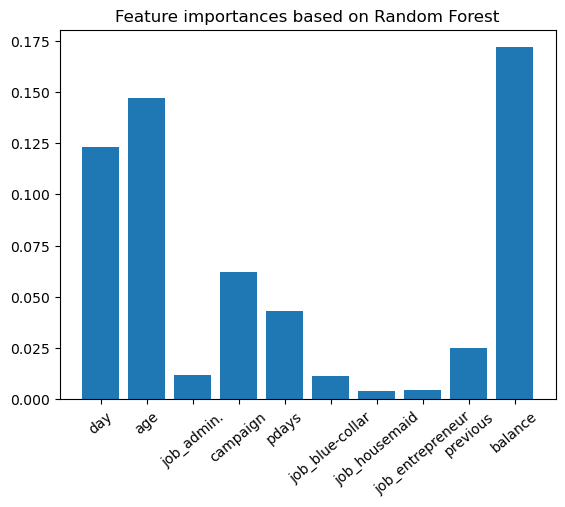

In [165]:
columns=scaled_data.columns
plt.title("Feature importances based on Random Forest")
plt.bar(range(len(features)),feature_imp[features])
plt.xticks(range(len(features)),columns[features],rotation=40)